<a href="https://colab.research.google.com/github/bforoura/ML26/blob/main/Module2_ML_Projects/ch2_overview.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **End-to-End Machine Learning Workflow**

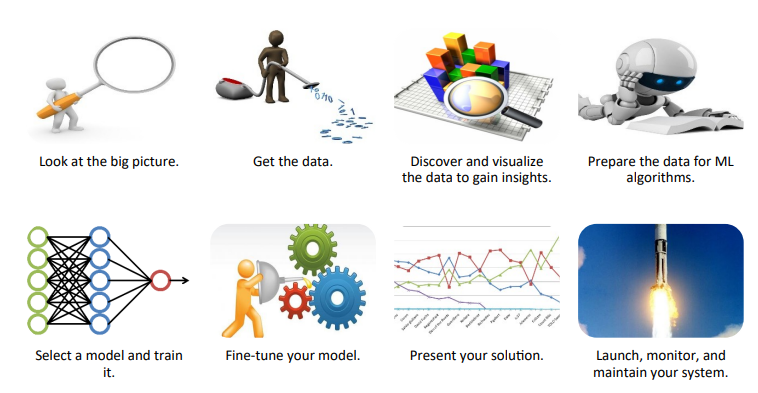
<br>

* This notebook showcases a few machine learning equations and practical Python code for studying the **California housing dataset**.

* The main goal is highlight the **ML workflow** we will use in this course.

# **Exploring the California Housing Dataset**

<br>

* The goal of this dataset is to learn from district-level attributes—such as population, median income, and housing median age—to predict the median housing price in any California district.


* The housing dataset consists of 20,640 rows and 10 attributes.
* There are 9 numerical features, including `longitude`, `latitude`, `housing_median_age`, `total_rooms`, `total_bedrooms`, `population`, `households`, `median_income`, and `median_house_value`.
* The single non-numeric attribute in the dataset is `ocean_proximity`.
* The `total_bedrooms` attribute contains 207 missing values, leaving 20,433 non-null entries out of the 20,640 total rows.

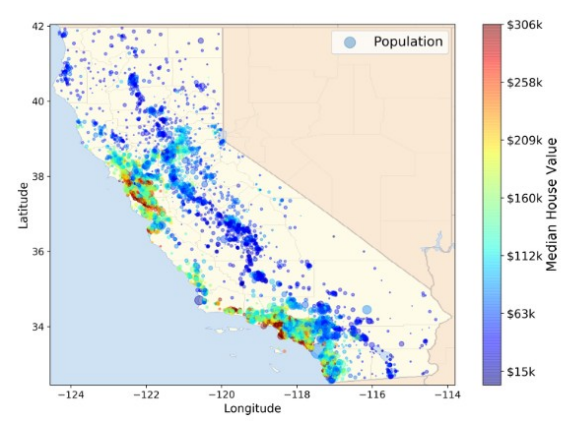

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

# Load the California housing dataset
housing_data = fetch_california_housing(as_frame=True)
df = housing_data.frame
print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


# **Pearson's Correlation Coefficient (r)**

<br>

* The standard correlation coefficient measures the linear relationship between pairs of attributes.

* It returns a value between -1 and 1 where -1 indicates a strong negative relationship, 1 indicates a strong positive relationship, and 0 indicates no relationship.

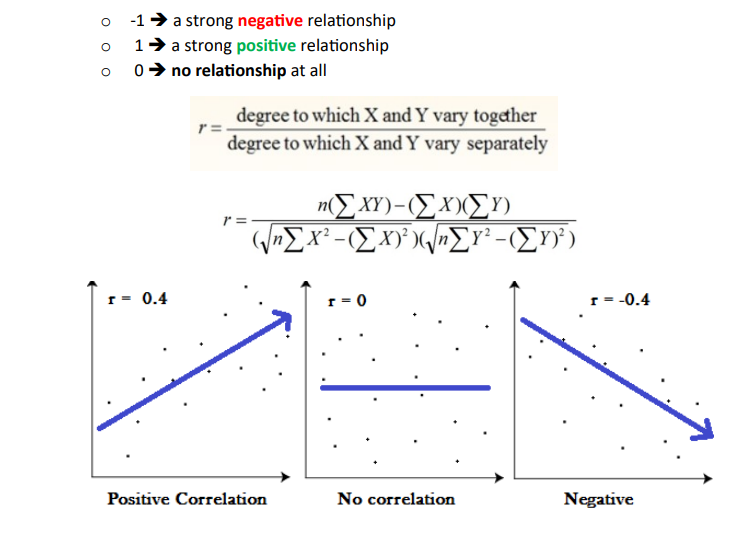

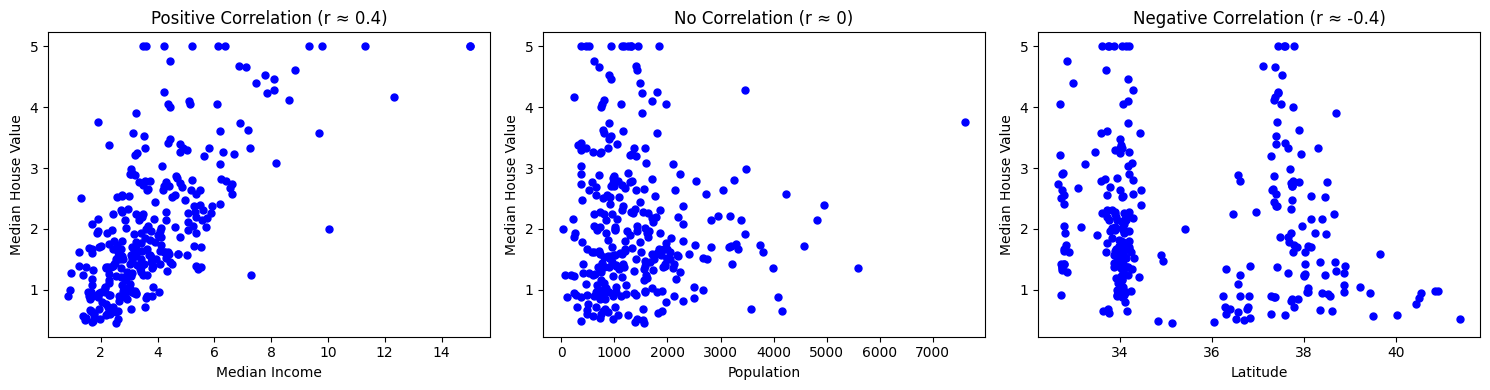

Manual Pearson's r (Median Income): 0.6881
Manual Pearson's r (Population): -0.0246
Manual Pearson's r (Latitude): -0.1442


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Take a random sample so individual points are clean and distinct
df_sample = df.sample(n=300, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Positive Correlation: Median Income vs Median House Value
axes[0].scatter(df_sample['MedInc'], df_sample['MedHouseVal'], color='blue', s=25)
axes[0].set_title("Positive Correlation (r ≈ 0.4)")
axes[0].set_xlabel("Median Income")
axes[0].set_ylabel("Median House Value")

# No Correlation: Population vs Median House Value
axes[1].scatter(df_sample['Population'], df_sample['MedHouseVal'], color='blue', s=25)
axes[1].set_title("No Correlation (r ≈ 0)")
axes[1].set_xlabel("Population")
axes[1].set_ylabel("Median House Value")

# Negative Correlation: Latitude vs Median House Value
axes[2].scatter(df_sample['Latitude'], df_sample['MedHouseVal'], color='blue', s=25)
axes[2].set_title("Negative Correlation (r ≈ -0.4)")
axes[2].set_xlabel("Latitude")
axes[2].set_ylabel("Median House Value")

plt.tight_layout()
plt.show()

def manual_pearson(x, y):
    n = len(x)
    sum_x = np.sum(x)
    sum_y = np.sum(y)
    sum_xy = np.sum(x * y)
    sum_x2 = np.sum(x**2)
    sum_y2 = np.sum(y**2)
    numerator = (n * sum_xy) - (sum_x * sum_y)
    denominator = np.sqrt((n * sum_x2 - sum_x**2) * (n * sum_y2 - sum_y**2))
    return numerator / denominator

print(f"Manual Pearson's r (Median Income): {manual_pearson(df['MedInc'], df['MedHouseVal']):.4f}")
print(f"Manual Pearson's r (Population): {manual_pearson(df['Population'], df['MedHouseVal']):.4f}")
print(f"Manual Pearson's r (Latitude): {manual_pearson(df['Latitude'], df['MedHouseVal']):.4f}")

# **Regression Model Performance: Error Rates**

<br>

* To evaluate regression models, we measure the magnitude of prediction errors.
* **Mean Squared Error**(MSE) uses the Euclidean $l_2$ norm, which squares errors and heavily penalizes large outliers.

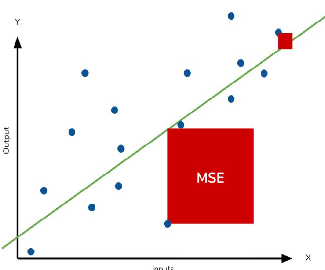

* **Mean Absolute Error** (MAE) uses the Manhattan $l_1$ norm, taking the absolute value of errors.

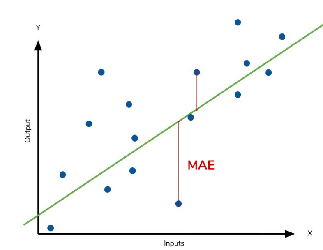


* The **coefficient of determination** ($R^2$) measures the proportion of variance explained by the model relative to a mean baseline.

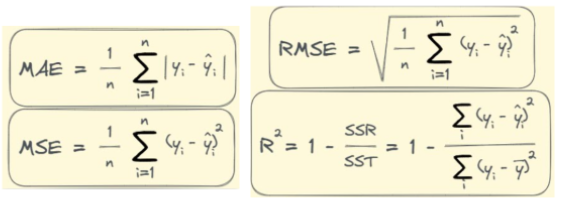

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_true = np.array([3.0, -0.5, 2.0, 7.0])
y_pred = np.array([2.5, 0.0, 2.0, 8.0])

# Mean Squared Error (Euclidean l2 norm)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)

# Mean Absolute Error (Manhattan l1 norm)
mae = mean_absolute_error(y_true, y_pred)

# R^2 Score
r2 = r2_score(y_true, y_pred)

print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"R^2: {r2}")

MSE: 0.375
RMSE: 0.6123724356957945
MAE: 0.5
R^2: 0.9486081370449679


# **Explanation**
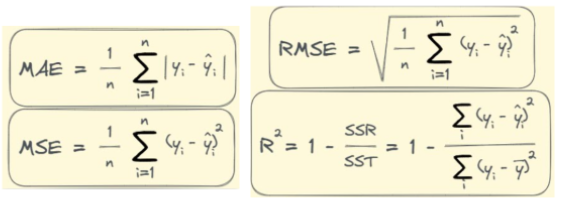
---
* MSE: 0.375
  * The average squared difference between the true values and the predicted values is 0.375.
  * Because errors are squared, this value places a higher weight on larger deviations.
---
* RMSE: 0.6124
  * The square root of the MSE, meaning that on average, the model's predictions miss the actual target values by approximately 0.6124 units in the original scale of the data.
---
* MAE: 0.5

  * The average absolute distance between the predictions and the actual values is 0.5 units.
  * Unlike MSE, this treats all errors linearly without heavily disproportionate penalties for larger misses.
---
* R^2: 0.9486

   * The model explains about 94.86% of the variance in the target values relative to a baseline mean model.
   
   * This indicates an exceptionally strong fit for this specific four-sample test set.

# **Classification Performance Metrics**

<br>

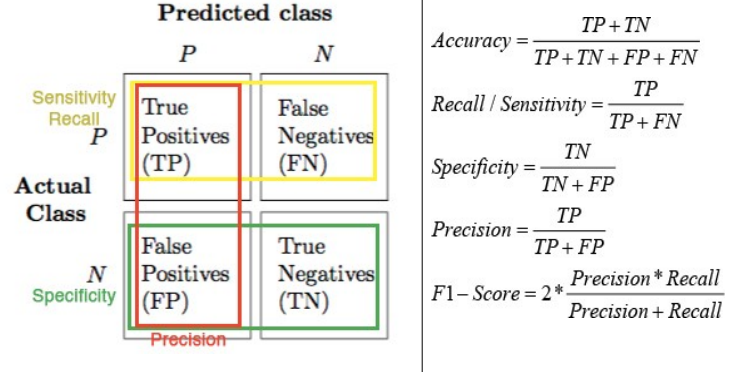

* For classification tasks, accuracy alone can be misleading under class imbalance.

* We evaluate performance using a confusion matrix containing True Positives (TP), True Negatives (TN), False Positives (FP), and False Negatives (FN).

* These allow us to calculate **precision**, **recall**, and **F1-score**.

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

expected = np.array(['nospam', 'nospam', 'spam', 'nospam', 'spam', 'spam', 'spam', 'nospam', 'nospam', 'spam'])
predicted = np.array(['spam', 'nospam', 'spam', 'nospam', 'nospam', 'spam', 'spam', 'nospam', 'spam', 'spam'])

labels = np.unique(expected)
cm = confusion_matrix(expected, predicted, labels=labels)
print("Confusion Matrix:\n", cm)

tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

Confusion Matrix:
 [[3 2]
 [1 4]]
Accuracy: 0.70
Precision: 0.67
Recall: 0.80
F1-Score: 0.73


# **Understanding the Classification Confusion Matrix and Metrics**
<br>


**Confusion Matrix Structure**

<br>

 * The rows represent the actual true labels (nospam and spam), and the columns represent the model's predicted labels.
 * Treating spam as the positive class, the breakdown is as follows:

      | Actual \ Predicted | Nospam | Spam |
      | :--- | :--- | :--- |
      | **Nospam** | 3 (True Negatives) | 2 (False Positives) |
      | **Spam** | 1 (False Negatives) | 4 (True Positives) |

* **Actual Nospam (Row 1):** 3 were correctly predicted as nospam, and 2 were incorrectly predicted as spam.
* **Actual Spam (Row 2):** 1 was incorrectly predicted as nospam, and 4 were correctly predicted as spam.


<br>

**Metric Meanings**

* **Accuracy (0.70):** The overall proportion of correct predictions across all samples, meaning 7 out of 10 instances were classified correctly.
* **Precision (0.67):** Out of all the instances the model predicted as spam, 67% of them were actually correct (4/6).
* **Recall (0.80):** Out of all the actual spam instances present in the true data, the model successfully identified 80% of them (4/5).
* **F1-Score (0.73):** The harmonic mean of precision and recall, providing a balanced summary metric that accounts for both false positives and false negatives.

# **K-Fold Cross-Validation**

<br>

* To ensure our model's performance is robust and not dependent on a single train-test split, we use K-fold cross-validation.

* This technique splits the dataset into $K$ subsets, training the model $K$ times, using each subset once as a validation set while the remaining $K-1$ subsets form the training set.

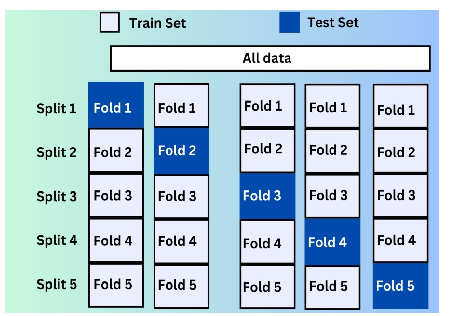

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
import numpy as np

# Generate sample features (X) and labels (y) for classification
X, y = make_classification(n_samples=100, n_features=4, random_state=42)

# Initialize the classifier
clf = RandomForestClassifier(random_state=42)

# Perform 5-fold cross-validation
scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')

print(f"Cross-Validation Scores: {scores}")
print(f"Mean Accuracy: {scores.mean():.4f}")
print(f"Standard Deviation: {scores.std():.4f}")

Cross-Validation Scores: [0.95 0.85 0.9  1.   1.  ]
Mean Accuracy: 0.9400
Standard Deviation: 0.0583


# **Understanding Cross-Validation Output**

<br>

* **Cross-Validation Scores ([0.95, 0.85, 0.90, 1.0, 1.0]):**

  * These represent the individual accuracy scores obtained from each of the 5 folds (splits) during the cross-validation process.
  
  * Each fold acts as the validation set once while the remaining folds are used for training.


* **Mean Accuracy (0.9400):**
  * The average accuracy across all 5 validation folds, indicating that the model correctly classifies roughly 94% of the samples overall.


* **Standard Deviation (0.0583):**

  * A measure of the dispersion or variability of the scores around the mean.
  * A low standard deviation indicates that the model's performance is stable and reliable across different subsets of the data rather than depending on a single fortunate train-test split.

# **Hyperparameter Tuning with Grid Search**

<br>

* Model performance often depends heavily on the choice of hyperparameters (such as maximum depth or number of estimators).

* Instead of manual tuning, we use **Grid Search** to systematically search through a specified subset of hyperparameters, evaluating each combination using cross-validation to find the optimal configuration.

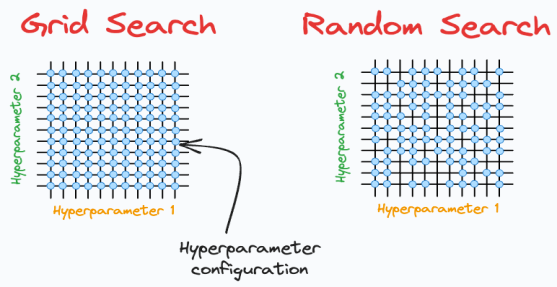

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification

# Generate sample data
X, y = make_classification(n_samples=100, n_features=4, random_state=42)

# Define the model
clf = RandomForestClassifier(random_state=42)

# Define the hyperparameter grid to search
param_grid = {
    'n_estimators': [10, 50, 100],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

# Initialize Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(estimator=clf, param_grid=param_grid, cv=5, scoring='accuracy')

# Fit to the data
grid_search.fit(X, y)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 10}
Best Cross-Validation Score: 0.9500


# **Understanding Hyperparameter Tuning Output**
<br>

* **Best Parameters:**
  * `max_depth: None`: Allows the decision trees to grow fully without a preset limit on depth, letting them split until all leaves are pure or contain fewer than the minimum sample split threshold.
  * `min_samples_split: 2`: Sets the minimum number of samples required to split an internal node to 2, allowing fine-grained splits.
  * `n_estimators: 10`: Specifies that the Random Forest ensemble utilizes 10 individual decision trees.
  
* **Best Cross-Validation Score (0.9500):** The highest average accuracy achieved across the cross-validation folds among all tested hyperparameter combinations, indicating that the optimized model configuration correctly classifies 95% of validation instances.

# **Visualizing Individual Trees in a Random Forest**

<br>

* Since a Random Forest consists of an ensemble of individual decision trees, we can use `matplotlib` and `sklearn.tree.plot_tree` to inspect and draw any specific tree from the trained model.

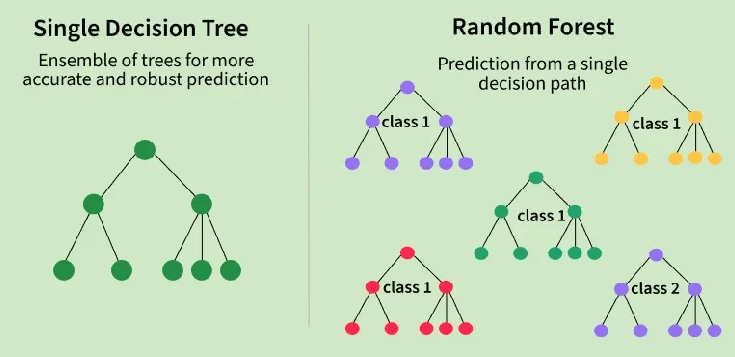

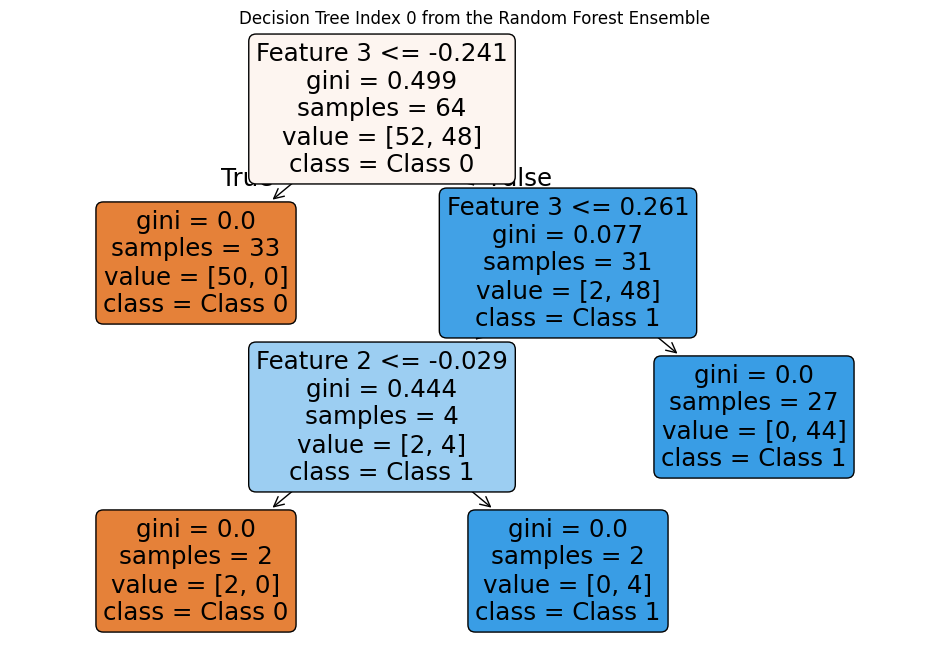

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import GridSearchCV
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Generate sample data and fit the grid search model
X, y = make_classification(n_samples=100, n_features=4, random_state=42)

param_grid = {
    'n_estimators': [10, 50, 100],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

clf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=clf, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(X, y)

# Retrieve the best model from the grid search
best_model = grid_search.best_estimator_

# Plot the first individual decision tree from the forest ensemble
plt.figure(figsize=(12, 8))
plot_tree(
    best_model.estimators_[0],
    feature_names=[f"Feature {i}" for i in range(X.shape[1])],
    class_names=['Class 0', 'Class 1'],
    filled=True,
    rounded=True
)
plt.title("Decision Tree Index 0 from the Random Forest Ensemble")
plt.show()

# **Feature Importances in Random Forests**

<br>

* Random Forests can quantify the relative importance of each feature in making predictions.

* **Feature importance** is calculated by measuring how much impurity-based splits decrease across all trees in the forest, helping identify which attributes drive the model's decisions.

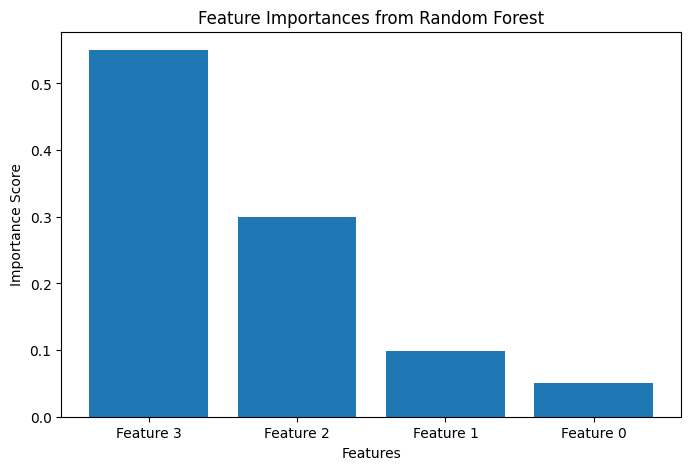

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract feature importances from the best estimator
importances = best_model.feature_importances_
feature_indices = np.argsort(importances)[::-1]

# Plot feature importances
plt.figure(figsize=(8, 5))
plt.bar(range(X.shape[1]), importances[feature_indices], align='center')
plt.xticks(range(X.shape[1]), [f"Feature {i}" for i in feature_indices])
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.title("Feature Importances from Random Forest")
plt.show()

# **Data Transformations and Scaling**

<br>

* Many machine learning algorithms perform poorly when numerical attributes have very different scales or tail-heavy distributions.

* To prepare features, we apply transformations such as **Min-Max scaling** (normalization), **standard scaling** (z-score normalization), or **log scaling**.

* Additionally, categorical text attributes like `ocean_proximity` must be converted into numerical representations using **One-Hot Encoding**.

* Scikit-learn's `ColumnTransformer` allows us to apply these distinct transformation pipelines simultaneously to both numerical and categorical columns.

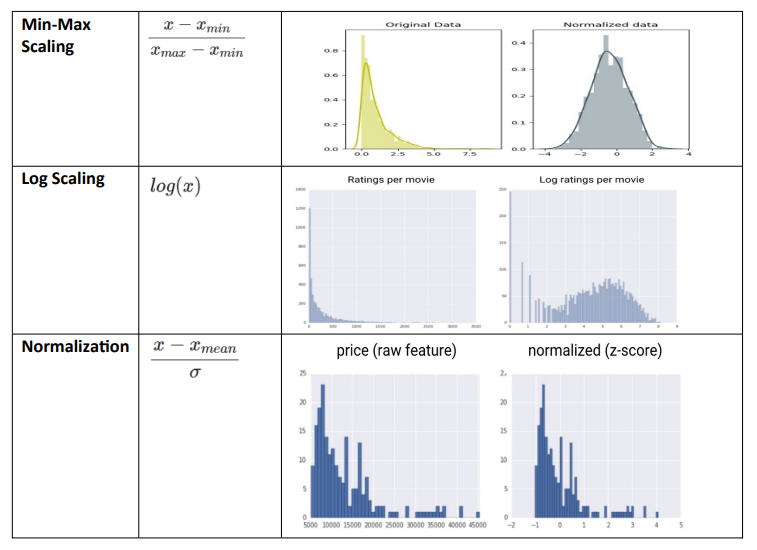

In [ ]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin

# Define sample housing dataframe with numerical and categorical attributes
housing = pd.DataFrame({
    'longitude': [-122.23, -122.22, -122.24],
    'latitude': [37.88, 37.86, 37.85],
    'housing_median_age': [41.0, 21.0, 52.0],
    'total_rooms': [880.0, 7099.0, 1467.0],
    'total_bedrooms': [129.0, 1106.0, 190.0],
    'population': [322.0, 2401.0, 496.0],
    'households': [126.0, 1138.0, 177.0],
    'median_income': [8.3252, 5.6421, 5.4659],
    'median_house_value': [452600.0, 358500.0, 352100.0],
    'ocean_proximity': ['NEAR BAY', '<1H OCEAN', 'NEAR BAY']
})

# Define custom transformer for combined attributes
rooms_ix, bedrooms_ix, population_ix, households_ix = 3, 4, 5, 6
class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room=True):
        self.add_bedrooms_per_room = add_bedrooms_per_room
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        rooms_per_household = X[:, rooms_ix] / X[:, households_ix]
        population_per_household = X[:, population_ix] / X[:, households_ix]
        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
            return np.c_[X, rooms_per_household, population_per_household, bedrooms_per_room]
        else:
            return np.c_[X, rooms_per_household, population_per_household]

# Numerical pipeline for imputing missing values, adding features, and scaling
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('attribs_adder', CombinedAttributesAdder()),
    ('std_scaler', StandardScaler()),
])

num_attribs = list(housing.drop("ocean_proximity", axis=1))
cat_attribs = ["ocean_proximity"]

# Full preprocessing pipeline using ColumnTransformer to handle all columns
full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", OneHotEncoder(), cat_attribs),
])

# Apply transformations to the full dataset
housing_prepared = full_pipeline.fit_transform(housing)

print(housing_prepared)

[[ 0.          1.33630621  0.23378595 -0.80920686 -0.77425914 -0.79747631
  -0.7611782   1.41207444  1.41192467 -0.21955915  0.23150544  0.24091063
   0.          1.        ]
 [ 1.22474487 -0.26726124 -1.32478705  1.40903769  1.41201595  1.41018447
   1.41279829 -0.63869973 -0.63630932 -1.10011518 -1.32397618  1.08638832
   1.          0.        ]
 [-1.22474487 -1.06904497  1.0910011  -0.59983083 -0.63775681 -0.61270816
  -0.65162009 -0.7733747  -0.77561535  1.31967434  1.09247074 -1.32729895
   0.          1.        ]]


# **Understanding Transformed Dataset Output**

<br>

* The `housing_prepared` array outputs a 2D NumPy matrix containing 3 rows (representing individual districts) and 14 columns.

* The first 12 columns contain the scaled numerical attributes and engineered features (`rooms_per_household`, `population_per_household`, and `bedrooms_per_room`) processed through the numerical pipeline.

* The final columns represent the binary indicator values generated by the `OneHotEncoder` applied to the `ocean_proximity` attribute.

* This unified matrix successfully merges disparate data types into a single numeric array that can be directly passed to machine learning estimators for training or prediction.

# **Categorical Attributes and One-Hot Encoding**
<br>

* Most machine learning algorithms prefer working with numbers.

* When dealing with categorical text attributes (such as `ocean_proximity`), we cannot simply assign ordered numbers (like 0, 1, 2) because algorithms would incorrectly assume that categories are numerically close or comparable.

* Instead, we use One-Hot Encoding to create a binary attribute for each category—introducing a new column with a value of 1 if the category is present and 0 otherwise.

* In Scikit-Learn, this is handled using the `OneHotEncoder` class.

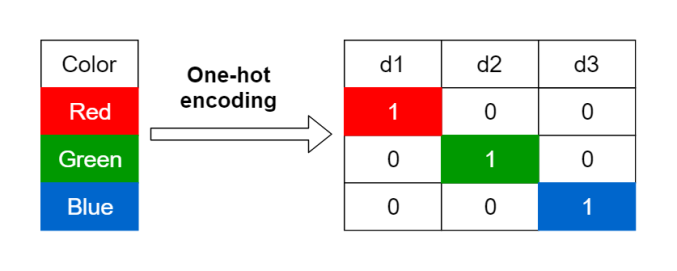

In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# Sample DataFrame with a categorical attribute
housing_cat = pd.DataFrame({
    'ocean_proximity': ['<1H OCEAN', 'INLAND', '<1H OCEAN', 'NEAR OCEAN', 'NEAR BAY']
})

# Initialize and fit the OneHotEncoder
cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

# Convert the resulting sparse matrix to a dense NumPy array for inspection
housing_cat_1hot_array = housing_cat_1hot.toarray()

# Display the encoded array and category feature names
print("One-Hot Encoded Array:")
print(housing_cat_1hot_array)
print("\nDetected Categories:")
print(cat_encoder.categories_)

One-Hot Encoded Array:
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]]

Detected Categories:
[array(['<1H OCEAN', 'INLAND', 'NEAR BAY', 'NEAR OCEAN'], dtype=object)]


# **Machine Learning Pipeline**

<br>

* An ML pipeline represents a sequence of data processing components that automates the machine learning workflow by enabling data to be transformed and correlated into a model that can achieve the desired results.

* Using Scikit-Learn's `Pipeline` class allows us to chain multiple preprocessing steps—such as handling missing values, adding custom attributes, and scaling features—into a single unified workflow.

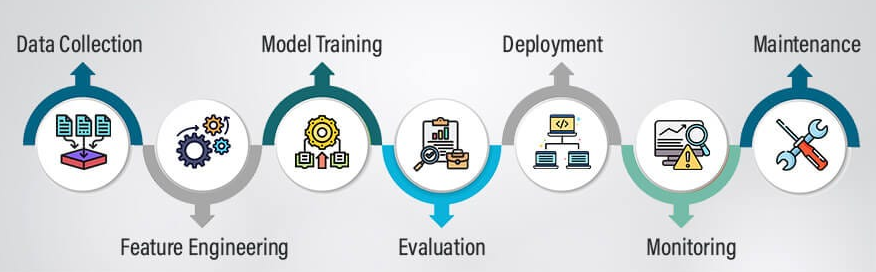

In [ ]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin

# Define a sample housing dataframe if `housing` is not already defined in your environment
housing = pd.DataFrame({
    'longitude': [-122.23, -122.22, -122.24],
    'latitude': [37.88, 37.86, 37.85],
    'housing_median_age': [41.0, 21.0, 52.0],
    'total_rooms': [880.0, 7099.0, 1467.0],
    'total_bedrooms': [129.0, 1106.0, 190.0],
    'population': [322.0, 2401.0, 496.0],
    'households': [126.0, 1138.0, 177.0],
    'median_income': [8.3252, 5.6421, 5.4659],
    'median_house_value': [452600.0, 358500.0, 352100.0],
    'ocean_proximity': ['NEAR BAY', 'NEAR BAY', 'NEAR BAY']
})

# Drop the text attribute to create the numerical dataframe as shown in the lecture notes[cite: 1]
housing_num = housing.drop("ocean_proximity", axis=1)

# Define custom transformer for combined attributes
rooms_ix, bedrooms_ix, population_ix, households_ix = 3, 4, 5, 6
class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room=True):
        self.add_bedrooms_per_room = add_bedrooms_per_room
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        rooms_per_household = X[:, rooms_ix] / X[:, households_ix]
        population_per_household = X[:, population_ix] / X[:, households_ix]
        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
            return np.c_[X, rooms_per_household, population_per_household, bedrooms_per_room]
        else:
            return np.c_[X, rooms_per_household, population_per_household]

# Construct the numerical processing pipeline[cite: 1]
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('attribs_adder', CombinedAttributesAdder()),
    ('std_scaler', StandardScaler()),
])

# Fit and transform the numerical dataset[cite: 1]
housing_num_tr = num_pipeline.fit_transform(housing_num)

print(housing_num_tr)

[[ 0.          1.33630621  0.23378595 -0.80920686 -0.77425914 -0.79747631
  -0.7611782   1.41207444  1.41192467 -0.21955915  0.23150544  0.24091063]
 [ 1.22474487 -0.26726124 -1.32478705  1.40903769  1.41201595  1.41018447
   1.41279829 -0.63869973 -0.63630932 -1.10011518 -1.32397618  1.08638832]
 [-1.22474487 -1.06904497  1.0910011  -0.59983083 -0.63775681 -0.61270816
  -0.65162009 -0.7733747  -0.77561535  1.31967434  1.09247074 -1.32729895]]


# **Understanding the Numerical Pipeline Output**

<br>

* The output is a 2D NumPy array consisting of 3 rows (representing each district in the sample dataframe) and 12 columns


* The columns contain the scaled values of the 9 original numerical attributes (`longitude`, `latitude`, `housing_median_age`, `total_rooms`, `total_bedrooms`, `population`, `households`, `median_income`, and `median_house_value`) along with the 3 custom engineered attributes (`rooms_per_household`, `population_per_household`, and `bedrooms_per_room`)

* All values have been transformed using `StandardScaler` to center them around a mean of 0 with a standard deviation of 1, ensuring features with larger numeric scales do not disproportionately influence the learning algorithm

* Missing values were first addressed via `SimpleImputer` using the median strategy, new attribute columns were appended by the `CombinedAttributesAdder` transformer, and the final dataset was normalized.